# Rossmann Retail Sales Forecasting & FP&A Analytics
## 05 — Historical Features, Residual Modelling, and Multi-Period Validation

### Phase objective

This notebook improves the Phase 4 benchmark without discarding its strongest feature: the store-specific historical pattern.

The analysis:

1. creates leakage-safe long-term and recent historical averages;
2. compares recent-history blends across three 48-day backtest periods;
3. trains a residual model that predicts a correction to the selected baseline;
4. compares the baseline, residual model, and blends across all folds;
5. evaluates open-store metrics separately from the full network.

All historical aggregates are frozen at the start of each forecast horizon.

> Stop at the review section. Do not commit until the results have been checked.

## 1. Imports and project paths

In [1]:
from pathlib import Path
from time import perf_counter
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import KFold

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.11.15
pandas: 2.3.3
NumPy: 2.4.6
scikit-learn: 1.9.0


In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Confirm that data/ and notebooks/ exist."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    MODEL_CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    build_feature_table,
)
from src.history_features import (
    BASELINE_CANDIDATE_COLUMNS,
    HISTORY_NUMERIC_FEATURES,
    add_historical_features,
)
from src.metrics import (
    bias_percentage,
    evaluate_regression,
    rmspe,
    wape,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Base model features: {len(MODEL_FEATURES)}")
print(f"Historical numeric features: {len(HISTORY_NUMERIC_FEATURES)}")

Project root: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting
Base model features: 34
Historical numeric features: 21


## 2. Rebuild the train and test feature tables

In [3]:
train = pd.read_csv(
    RAW_DATA_DIR / "train.csv",
    low_memory=False,
)
test = pd.read_csv(
    RAW_DATA_DIR / "test.csv",
    low_memory=False,
)
store = pd.read_csv(
    RAW_DATA_DIR / "store.csv",
    low_memory=False,
)

train_features = build_feature_table(
    train,
    store,
    dataset_name="train",
)
test_features = build_feature_table(
    test,
    store,
    dataset_name="test",
)

display(
    pd.DataFrame(
        {
            "dataset": ["train", "test"],
            "rows": [len(train_features), len(test_features)],
            "stores": [
                train_features["Store"].nunique(),
                test_features["Store"].nunique(),
            ],
            "minimum_date": [
                train_features["Date"].min(),
                test_features["Date"].min(),
            ],
            "maximum_date": [
                train_features["Date"].max(),
                test_features["Date"].max(),
            ],
        }
    )
)

,dataset,rows,stores,minimum_date,maximum_date
0,train,1017209,1115,2013-01-01,2015-07-31
1,test,41088,856,2015-08-01,2015-09-17


## 3. Define three non-overlapping 48-day backtest folds

Each fold uses the same 856-store population as the Kaggle test and only earlier observations to build historical averages.

In [4]:
test_store_ids = set(test_features["Store"].unique())
horizon_days = test_features["Date"].nunique()
final_historical_date = train_features["Date"].max()

fold_rows = []

for fold_number, periods_back in enumerate([2, 1, 0], start=1):
    fold_end = (
        final_historical_date
        - pd.Timedelta(days=horizon_days * periods_back)
    )
    fold_start = (
        fold_end
        - pd.Timedelta(days=horizon_days - 1)
    )

    fold_rows.append(
        {
            "fold": f"Fold {fold_number}",
            "validation_start": fold_start,
            "validation_end": fold_end,
        }
    )

fold_definition = pd.DataFrame(fold_rows)
fold_definition["days"] = (
    fold_definition["validation_end"]
    - fold_definition["validation_start"]
).dt.days + 1

display(fold_definition)

assert (fold_definition["days"] == horizon_days).all()

,fold,validation_start,validation_end,days
0,Fold 1,2015-03-10,2015-04-26,48
1,Fold 2,2015-04-27,2015-06-13,48
2,Fold 3,2015-06-14,2015-07-31,48


## 4. Evaluation helpers

In [5]:
def complete_open_closed_prediction(
    scoring_data: pd.DataFrame,
    open_prediction: pd.Series,
) -> pd.Series:
    prediction = pd.Series(0.0, index=scoring_data.index)

    open_index = scoring_data.index[
        scoring_data["OpenFilled"] == 1
    ]

    prediction.loc[open_index] = np.clip(
        open_prediction.loc[open_index],
        a_min=0,
        a_max=None,
    )

    return prediction


def evaluate_candidate(
    scoring_data: pd.DataFrame,
    prediction: pd.Series,
    *,
    model_name: str,
    fold_name: str,
    validation_start: pd.Timestamp,
    validation_end: pd.Timestamp,
    fit_seconds: float = 0.0,
) -> dict[str, object]:
    all_result = evaluate_regression(
        scoring_data["Sales"],
        prediction,
        model_name=model_name,
        fit_seconds=fit_seconds,
    ).iloc[0]

    open_mask = scoring_data["OpenFilled"] == 1
    open_actual = scoring_data.loc[open_mask, "Sales"]
    open_prediction = prediction.loc[open_mask]

    return {
        "fold": fold_name,
        "validation_start": validation_start,
        "validation_end": validation_end,
        "model": model_name,
        "rmspe": all_result["rmspe"],
        "wape_all_rows": all_result["wape"],
        "bias_all_rows_pct": all_result["bias_pct"],
        "mae_all_rows": all_result["mae"],
        "wape_open_rows": wape(open_actual, open_prediction),
        "bias_open_rows_pct": bias_percentage(
            open_actual,
            open_prediction,
        ),
        "mae_open_rows": np.abs(
            open_actual.to_numpy()
            - open_prediction.to_numpy()
        ).mean(),
        "evaluation_rows": len(scoring_data),
        "open_rows": int(open_mask.sum()),
        "fit_seconds": fit_seconds,
    }

## 5. Multi-period comparison of historical baselines

The candidates compare long-term history, recent 180- and 365-day history, and three long/recent blends.

In [6]:
baseline_backtest_rows = []
baseline_fold_predictions = {}

for fold_row in fold_definition.itertuples(index=False):
    fold_name = fold_row.fold
    validation_start = pd.Timestamp(fold_row.validation_start)
    validation_end = pd.Timestamp(fold_row.validation_end)

    reference_open = train_features.loc[
        (train_features["Date"] < validation_start)
        & (train_features["OpenFilled"] == 1)
    ].copy()

    scoring_data = train_features.loc[
        train_features["Date"].between(
            validation_start,
            validation_end,
        )
        & train_features["Store"].isin(test_store_ids)
    ].copy()

    scoring_with_history = add_historical_features(
        reference_open,
        scoring_data,
        cutoff_date=validation_start,
    )

    fold_prediction_columns = {}

    for model_name, column_name in BASELINE_CANDIDATE_COLUMNS.items():
        open_prediction = scoring_with_history.loc[
            scoring_with_history["OpenFilled"] == 1,
            column_name,
        ]

        full_prediction = complete_open_closed_prediction(
            scoring_with_history,
            open_prediction,
        )

        baseline_backtest_rows.append(
            evaluate_candidate(
                scoring_with_history,
                full_prediction,
                model_name=model_name,
                fold_name=fold_name,
                validation_start=validation_start,
                validation_end=validation_end,
            )
        )

        fold_prediction_columns[model_name] = full_prediction

    baseline_fold_predictions[fold_name] = {
        "data": scoring_with_history,
        "predictions": fold_prediction_columns,
    }

baseline_backtest = pd.DataFrame(baseline_backtest_rows)

display(
    baseline_backtest.sort_values(
        ["fold", "rmspe"]
    )
)

,fold,validation_start,validation_end,model,rmspe,wape_all_rows,bias_all_rows_pct,mae_all_rows,wape_open_rows,bias_open_rows_pct,mae_open_rows,evaluation_rows,open_rows,fit_seconds
1,Fold 1,2015-03-10,2015-04-26,Recent 365-day Store + weekday + Promo,0.1479,0.1045,-2.5248,585.4434,0.1045,-2.5248,716.3187,41088,33581,0.0000
4,Fold 1,2015-03-10,2015-04-26,50% recent 180-day blend,0.1503,0.1070,-3.0094,599.2889,0.1070,-3.0094,733.2593,41088,33581,0.0000
5,Fold 1,2015-03-10,2015-04-26,75% recent 180-day blend,0.1509,0.1068,-2.5261,598.2573,0.1068,-2.5261,731.9971,41088,33581,0.0000
3,Fold 1,2015-03-10,2015-04-26,25% recent 180-day blend,0.1529,0.1093,-3.4927,612.3902,0.1093,-3.4927,749.2894,41088,33581,0.0000
2,Fold 1,2015-03-10,2015-04-26,Recent 180-day Store + weekday + Promo,0.1548,0.1088,-2.0428,609.4636,0.1088,-2.0428,745.7085,41088,33581,0.0000
0,Fold 1,2015-03-10,2015-04-26,Long-term Store + weekday + Promo,0.1586,0.1138,-3.9760,637.7594,0.1138,-3.9760,780.3298,41088,33581,0.0000
7,Fold 2,2015-04-27,2015-06-13,Recent 365-day Store + weekday + Promo,0.1511,0.1045,-5.3546,621.2522,0.1045,-5.3546,775.1598,41088,32930,0.0000
11,Fold 2,2015-04-27,2015-06-13,75% recent 180-day blend,0.1540,0.1056,-4.4347,627.6221,0.1056,-4.4347,783.1077,41088,32930,0.0000
10,Fold 2,2015-04-27,2015-06-13,50% recent 180-day blend,0.1552,0.1080,-5.3353,641.9118,0.1080,-5.3353,800.9375,41088,32930,0.0000
8,Fold 2,2015-04-27,2015-06-13,Recent 180-day Store + weekday + Promo,0.1558,0.1058,-3.5341,629.0400,0.1058,-3.5341,784.8768,41088,32930,0.0000


In [19]:
baseline_model_summary = (
    baseline_backtest.groupby("model", as_index=False)
    .agg(
        mean_rmspe=("rmspe", "mean"),
        std_rmspe=("rmspe", "std"),
        minimum_rmspe=("rmspe", "min"),
        maximum_rmspe=("rmspe", "max"),
        mean_wape_open=("wape_open_rows", "mean"),
        mean_bias_open_pct=("bias_open_rows_pct", "mean"),
    )
    .sort_values("mean_rmspe")
    .reset_index(drop=True)
)

display(baseline_model_summary)

selected_baseline_name = baseline_model_summary.loc[0, "model"]
selected_baseline_column = BASELINE_CANDIDATE_COLUMNS[
    selected_baseline_name
]

print(f"Selected historical baseline: {selected_baseline_name}")
print(
    "Average backtest RMSPE: "
    f"{baseline_model_summary.loc[0, 'mean_rmspe']:.4f}"
)

,model,mean_rmspe,std_rmspe,minimum_rmspe,maximum_rmspe,mean_wape_open,mean_bias_open_pct
0,Recent 365-day Store + weekday + Promo,0.1445,0.0088,0.1345,0.1511,0.1019,-2.7289
1,50% recent 180-day blend,0.1481,0.0084,0.1388,0.1552,0.1051,-3.0017
2,75% recent 180-day blend,0.1485,0.0070,0.1406,0.1540,0.1044,-2.2540
3,25% recent 180-day blend,0.1508,0.0097,0.1402,0.1593,0.1082,-3.7494
4,Recent 180-day Store + weekday + Promo,0.1521,0.0055,0.1457,0.1558,0.1061,-1.5063
5,Long-term Store + weekday + Promo,0.1565,0.0107,0.1449,0.1661,0.1135,-4.4972


Selected historical baseline: Recent 365-day Store + weekday + Promo
Average backtest RMSPE: 0.1445


## 6. Residual modelling design

For each validation fold, the immediately preceding 48 days form a calibration period.

The residual model learns:

```text
log1p(actual sales) - log1p(selected historical baseline)
```

The sequence is strictly chronological:

1. historical reference before calibration;
2. calibration block used to train the residual model;
3. validation block used only for scoring.

In [8]:
RESIDUAL_NUMERIC_FEATURES = list(
    dict.fromkeys(
        MODEL_NUMERIC_FEATURES
        + HISTORY_NUMERIC_FEATURES
    )
)

RESIDUAL_CATEGORICAL_FEATURES = MODEL_CATEGORICAL_FEATURES

RESIDUAL_MODEL_FEATURES = (
    RESIDUAL_NUMERIC_FEATURES
    + RESIDUAL_CATEGORICAL_FEATURES
)

print(
    f"Residual numeric features: "
    f"{len(RESIDUAL_NUMERIC_FEATURES)}"
)
print(
    f"Residual categorical features: "
    f"{len(RESIDUAL_CATEGORICAL_FEATURES)}"
)
print(
    f"Residual total features: "
    f"{len(RESIDUAL_MODEL_FEATURES)}"
)

Residual numeric features: 50
Residual categorical features: 5
Residual total features: 55


In [20]:
def build_residual_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                RESIDUAL_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                TargetEncoder(
                    target_type="continuous",
                    smooth="auto",
                    cv=KFold(
                        n_splits=5,
                        shuffle=True,
                        random_state=42,
                    ),
                ),
                RESIDUAL_CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    regressor = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.04,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=25,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", regressor),
        ]
    )

## 7. Backtest the residual model and prediction blends

The comparison includes:

- selected historical baseline;
- residual-adjusted HGB;
- 50% baseline / 50% residual;
- 25% baseline / 75% residual.

In [21]:
residual_backtest_rows = []
residual_fold_outputs = {}
residual_fit_summary_rows = []

for fold_row in fold_definition.itertuples(index=False):
    fold_name = fold_row.fold
    validation_start = pd.Timestamp(fold_row.validation_start)
    validation_end = pd.Timestamp(fold_row.validation_end)

    calibration_end = validation_start - pd.Timedelta(days=1)
    calibration_start = (
        calibration_end
        - pd.Timedelta(days=horizon_days - 1)
    )

    reference_before_calibration = train_features.loc[
        (train_features["Date"] < calibration_start)
        & (train_features["OpenFilled"] == 1)
    ].copy()

    calibration_data = train_features.loc[
        train_features["Date"].between(
            calibration_start,
            calibration_end,
        )
    ].copy()

    calibration_with_history = add_historical_features(
        reference_before_calibration,
        calibration_data,
        cutoff_date=calibration_start,
    )

    calibration_model_rows = calibration_with_history.loc[
        calibration_with_history["OpenFilled"] == 1
    ].copy()

    calibration_model_rows["ResidualTarget"] = (
        np.log1p(calibration_model_rows["Sales"])
        - np.log1p(
            calibration_model_rows[
                selected_baseline_column
            ]
        )
    )

    scoring_reference_open = train_features.loc[
        (train_features["Date"] < validation_start)
        & (train_features["OpenFilled"] == 1)
    ].copy()

    scoring_data = train_features.loc[
        train_features["Date"].between(
            validation_start,
            validation_end,
        )
        & train_features["Store"].isin(test_store_ids)
    ].copy()

    scoring_with_history = add_historical_features(
        scoring_reference_open,
        scoring_data,
        cutoff_date=validation_start,
    )

    residual_model = build_residual_pipeline()
    fit_start = perf_counter()

    residual_model.fit(
        calibration_model_rows[RESIDUAL_MODEL_FEATURES],
        calibration_model_rows["ResidualTarget"],
    )

    fit_seconds = perf_counter() - fit_start

    scoring_open_mask = (
        scoring_with_history["OpenFilled"] == 1
    )

    predicted_residual = pd.Series(
        residual_model.predict(
            scoring_with_history.loc[
                scoring_open_mask,
                RESIDUAL_MODEL_FEATURES,
            ]
        ),
        index=scoring_with_history.index[
            scoring_open_mask
        ],
    )

    baseline_open = scoring_with_history.loc[
        scoring_open_mask,
        selected_baseline_column,
    ]

    residual_adjusted_open = pd.Series(
        np.expm1(
            np.log1p(baseline_open)
            + predicted_residual
        ),
        index=baseline_open.index,
    ).clip(lower=0)

    baseline_full = complete_open_closed_prediction(
        scoring_with_history,
        baseline_open,
    )

    residual_full = complete_open_closed_prediction(
        scoring_with_history,
        residual_adjusted_open,
    )

    blend_50_full = (
        0.50 * baseline_full
        + 0.50 * residual_full
    )

    blend_75_residual_full = (
        0.25 * baseline_full
        + 0.75 * residual_full
    )

    prediction_options = {
        selected_baseline_name: baseline_full,
        "Residual HGB": residual_full,
        "50% baseline / 50% residual": blend_50_full,
        "25% baseline / 75% residual": blend_75_residual_full,
    }

    for model_name, prediction in prediction_options.items():
        residual_backtest_rows.append(
            evaluate_candidate(
                scoring_with_history,
                prediction,
                model_name=model_name,
                fold_name=fold_name,
                validation_start=validation_start,
                validation_end=validation_end,
                fit_seconds=(
                    fit_seconds
                    if model_name != selected_baseline_name
                    else 0.0
                ),
            )
        )

    residual_fit_summary_rows.append(
        {
            "fold": fold_name,
            "calibration_start": calibration_start,
            "calibration_end": calibration_end,
            "calibration_rows": len(calibration_model_rows),
            "fit_seconds": fit_seconds,
            "iterations": (
                residual_model
                .named_steps["regressor"]
                .n_iter_
            ),
        }
    )

    residual_fold_outputs[fold_name] = {
        "data": scoring_with_history,
        "predictions": prediction_options,
    }

residual_backtest = pd.DataFrame(residual_backtest_rows)
residual_fit_summary = pd.DataFrame(
    residual_fit_summary_rows
)

display(
    residual_backtest.sort_values(
        ["fold", "rmspe"]
    )
)
display(residual_fit_summary)

,fold,validation_start,validation_end,model,rmspe,wape_all_rows,bias_all_rows_pct,mae_all_rows,wape_open_rows,bias_open_rows_pct,mae_open_rows,evaluation_rows,open_rows,fit_seconds
3,Fold 1,2015-03-10,2015-04-26,25% baseline / 75% residual,0.1377,0.0970,-3.0201,543.5707,0.0970,-3.0201,665.0854,41088,33581,3.0155
1,Fold 1,2015-03-10,2015-04-26,Residual HGB,0.1385,0.0980,-3.1853,549.0358,0.0980,-3.1853,671.7722,41088,33581,3.0155
2,Fold 1,2015-03-10,2015-04-26,50% baseline / 50% residual,0.1390,0.0979,-2.8550,548.5339,0.0979,-2.8550,671.1582,41088,33581,3.0155
0,Fold 1,2015-03-10,2015-04-26,Recent 365-day Store + weekday + Promo,0.1479,0.1045,-2.5248,585.4434,0.1045,-2.5248,716.3187,41088,33581,0.0000
4,Fold 2,2015-04-27,2015-06-13,Recent 365-day Store + weekday + Promo,0.1511,0.1045,-5.3546,621.2522,0.1045,-5.3546,775.1598,41088,32930,0.0000
6,Fold 2,2015-04-27,2015-06-13,50% baseline / 50% residual,0.1582,0.1098,-3.1169,652.7333,0.1098,-3.1169,814.4399,41088,32930,3.8723
7,Fold 2,2015-04-27,2015-06-13,25% baseline / 75% residual,0.1785,0.1258,-1.9980,747.5446,0.1258,-1.9980,932.7395,41088,32930,3.8723
5,Fold 2,2015-04-27,2015-06-13,Residual HGB,0.2063,0.1476,-0.8791,877.3732,0.1476,-0.8791,"1,094.7316",41088,32930,3.8723
8,Fold 3,2015-06-14,2015-07-31,Recent 365-day Store + weekday + Promo,0.1345,0.0967,-0.3072,587.0270,0.0967,-0.3072,684.0158,41088,35262,0.0000
10,Fold 3,2015-06-14,2015-07-31,50% baseline / 50% residual,0.1353,0.0942,2.4606,571.5081,0.0942,2.4606,665.9329,41088,35262,2.8634


,fold,calibration_start,calibration_end,calibration_rows,fit_seconds,iterations
0,Fold 1,2015-01-21,2015-03-09,45754,3.0155,350
1,Fold 2,2015-03-10,2015-04-26,43722,3.8723,350
2,Fold 3,2015-04-27,2015-06-13,43066,2.8634,350


In [28]:
residual_model_summary = (
    residual_backtest.groupby(
        "model",
        as_index=False,
    )
    .agg(
        mean_rmspe=("rmspe", "mean"),
        std_rmspe=("rmspe", "std"),
        minimum_rmspe=("rmspe", "min"),
        maximum_rmspe=("rmspe", "max"),
        mean_wape_open=(
            "wape_open_rows",
            "mean",
        ),
        mean_bias_open_pct=(
            "bias_open_rows_pct",
            "mean",
        ),
        mean_fit_seconds=(
            "fit_seconds",
            "mean",
        ),
    )
    .sort_values(
        "mean_rmspe",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(residual_model_summary)

fold_winners = (
    residual_backtest.loc[
        residual_backtest.groupby("fold")["rmspe"].idxmin(),
        [
            "fold",
            "model",
            "rmspe",
        ],
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

display(fold_winners)

lowest_mean_model = residual_model_summary.loc[
    0,
    "model",
]

# Robust selection:
# the recent 365-day baseline wins two of the three folds,
# has lower variability, and performs best in the final fold.
selected_phase5_model = selected_baseline_name

selected_phase5_row = residual_model_summary.loc[
    residual_model_summary["model"].eq(
        selected_phase5_model
    )
].iloc[0]

print(
    "Model with the lowest mean RMSPE: "
    f"{lowest_mean_model}"
)

print(
    "Selected robust Phase 5 model: "
    f"{selected_phase5_model}"
)

print(
    "Average three-fold RMSPE: "
    f"{selected_phase5_row['mean_rmspe']:.4f}"
)

print(
    "RMSPE standard deviation: "
    f"{selected_phase5_row['std_rmspe']:.4f}"
)

,model,mean_rmspe,std_rmspe,minimum_rmspe,maximum_rmspe,mean_wape_open,mean_bias_open_pct,mean_fit_seconds
0,50% baseline / 50% residual,0.1442,0.0123,0.1353,0.1582,0.1006,-1.1704,3.2504
1,Recent 365-day Store + weekday + Promo,0.1445,0.0088,0.1345,0.1511,0.1019,-2.7289,0.0000
2,25% baseline / 75% residual,0.1532,0.0222,0.1377,0.1785,0.1076,-0.3912,3.2504
3,Residual HGB,0.1667,0.0353,0.1385,0.2063,0.1184,0.3880,3.2504


,fold,model,rmspe
0,Fold 1,25% baseline / 75% residual,0.1377
1,Fold 2,Recent 365-day Store + weekday + Promo,0.1511
2,Fold 3,Recent 365-day Store + weekday + Promo,0.1345


Model with the lowest mean RMSPE: 50% baseline / 50% residual
Selected robust Phase 5 model: Recent 365-day Store + weekday + Promo
Average three-fold RMSPE: 0.1445
RMSPE standard deviation: 0.0088


## 8. Compare Phase 4 and Phase 5 on the final validation fold

In [29]:
final_fold_name = fold_definition.iloc[-1]["fold"]

final_fold_data = (
    residual_fold_outputs[final_fold_name]["data"]
    .copy()
)
final_fold_predictions = (
    residual_fold_outputs[final_fold_name]["predictions"]
)

final_fold_comparison_rows = []

for model_name, prediction in final_fold_predictions.items():
    final_fold_comparison_rows.append(
        evaluate_candidate(
            final_fold_data,
            prediction,
            model_name=model_name,
            fold_name=final_fold_name,
            validation_start=final_fold_data["Date"].min(),
            validation_end=final_fold_data["Date"].max(),
        )
    )

final_fold_comparison = (
    pd.DataFrame(final_fold_comparison_rows)
    .sort_values("rmspe")
    .reset_index(drop=True)
)

display(final_fold_comparison)

,fold,validation_start,validation_end,model,rmspe,wape_all_rows,bias_all_rows_pct,mae_all_rows,wape_open_rows,bias_open_rows_pct,mae_open_rows,evaluation_rows,open_rows,fit_seconds
0,Fold 3,2015-06-14,2015-07-31,Recent 365-day Store + weekday + Promo,0.1345,0.0967,-0.3072,587.0270,0.0967,-0.3072,684.0158,41088,35262,0.0000
1,Fold 3,2015-06-14,2015-07-31,50% baseline / 50% residual,0.1353,0.0942,2.4606,571.5081,0.0942,2.4606,665.9329,41088,35262,0.0000
2,Fold 3,2015-06-14,2015-07-31,25% baseline / 75% residual,0.1432,0.1000,3.8445,607.0224,0.1000,3.8445,707.3149,41088,35262,0.0000
3,Fold 3,2015-06-14,2015-07-31,Residual HGB,0.1553,0.1097,5.2284,665.7210,0.1097,5.2284,775.7117,41088,35262,0.0000


## 9. Final-fold diagnostics for the selected Phase 5 model

In [30]:
selected_final_prediction = final_fold_predictions[
    selected_phase5_model
]

final_fold_prediction_table = final_fold_data[
    [
        "Store",
        "Date",
        "DayOfWeek",
        "Promo",
        "SchoolHoliday",
        "StateHoliday",
        "StoreType",
        "Assortment",
        "OpenFilled",
        "Sales",
        selected_baseline_column,
        "Trend180VsLong",
        "Trend365VsLong",
    ]
].copy()

final_fold_prediction_table["Prediction"] = (
    selected_final_prediction
)

final_fold_prediction_table["AbsoluteError"] = (
    final_fold_prediction_table["Prediction"]
    - final_fold_prediction_table["Sales"]
).abs()

daily_phase5_predictions = (
    final_fold_prediction_table.groupby(
        "Date",
        as_index=False,
    )
    .agg(
        actual_sales=("Sales", "sum"),
        predicted_sales=("Prediction", "sum"),
        open_stores=("OpenFilled", "sum"),
    )
)

daily_phase5_predictions["absolute_error"] = (
    daily_phase5_predictions["predicted_sales"]
    - daily_phase5_predictions["actual_sales"]
).abs()

display(daily_phase5_predictions.head())
display(daily_phase5_predictions.tail())

,Date,actual_sales,predicted_sales,open_stores,absolute_error
0,2015-06-14,219309,"203,390.2567",27,"15,918.7433"
1,2015-06-15,8698635,"8,167,890.9580",855,"530,744.0420"
2,2015-06-16,7273996,"6,890,737.7801",855,"383,258.2199"
3,2015-06-17,6533120,"6,544,435.4597",855,"11,315.4597"
4,2015-06-18,6194895,"6,536,050.7290",855,"341,155.7290"


,Date,actual_sales,predicted_sales,open_stores,absolute_error
43,2015-07-27,8121049,"8,175,165.2914",856,"54,116.2914"
44,2015-07-28,6917617,"6,896,955.3185",856,"20,661.6815"
45,2015-07-29,6488169,"6,550,033.4597",856,"61,864.4597"
46,2015-07-30,6729611,"6,541,059.2290",856,"188,551.7710"
47,2015-07-31,7757358,"6,669,498.2379",856,"1,087,859.7621"


In [31]:
weekday_phase5_diagnostics = []

for day, group_data in final_fold_prediction_table.groupby(
    "DayOfWeek"
):
    weekday_phase5_diagnostics.append(
        {
            "DayOfWeek": day,
            "rows": len(group_data),
            "actual_sales": group_data["Sales"].sum(),
            "predicted_sales": group_data["Prediction"].sum(),
            "rmspe": rmspe(
                group_data["Sales"],
                group_data["Prediction"],
            ),
            "bias_pct": bias_percentage(
                group_data["Sales"],
                group_data["Prediction"],
            ),
        }
    )

weekday_phase5_diagnostics = pd.DataFrame(
    weekday_phase5_diagnostics
)

display(weekday_phase5_diagnostics)

,DayOfWeek,rows,actual_sales,predicted_sales,rmspe,bias_pct
0,1,5992,50159856,"48,555,457.1932",0.1237,-3.1986
1,2,5992,44264845,"42,772,775.5250",0.1365,-3.3708
2,3,5992,40850675,"40,341,545.9144",0.1156,-1.2463
3,4,5992,40532226,"40,572,463.9302",0.1164,0.0993
4,5,5992,42152721,"42,866,397.2195",0.1400,1.6931
5,6,5136,29875079,"32,097,212.2706",0.1701,7.4381
6,7,5992,1564000,"1,427,352.9633",0.1996,-8.7370


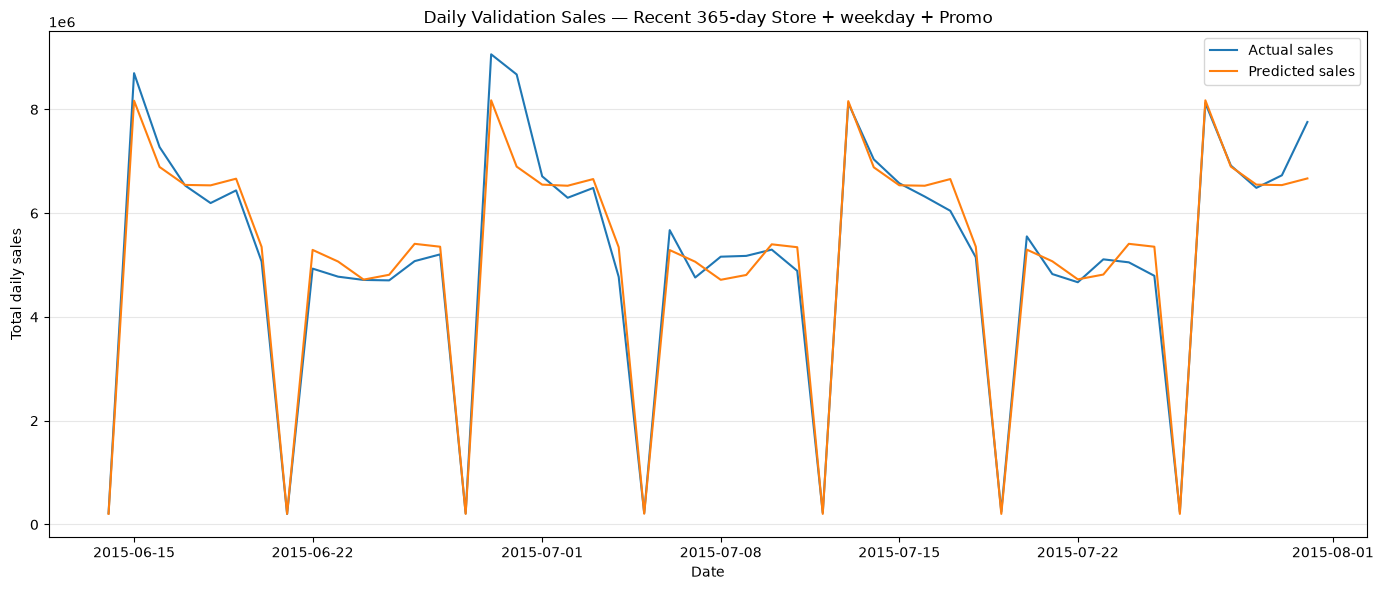

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_phase5_predictions["Date"],
    daily_phase5_predictions["actual_sales"],
    label="Actual sales",
)

ax.plot(
    daily_phase5_predictions["Date"],
    daily_phase5_predictions["predicted_sales"],
    label="Predicted sales",
)

ax.set_title(
    "Daily Validation Sales — "
    f"{selected_phase5_model}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Total daily sales")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

phase5_daily_figure_path = (
    REPORT_FIGURES_DIR
    / "phase5_daily_actual_vs_predicted.png"
)

fig.savefig(
    phase5_daily_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

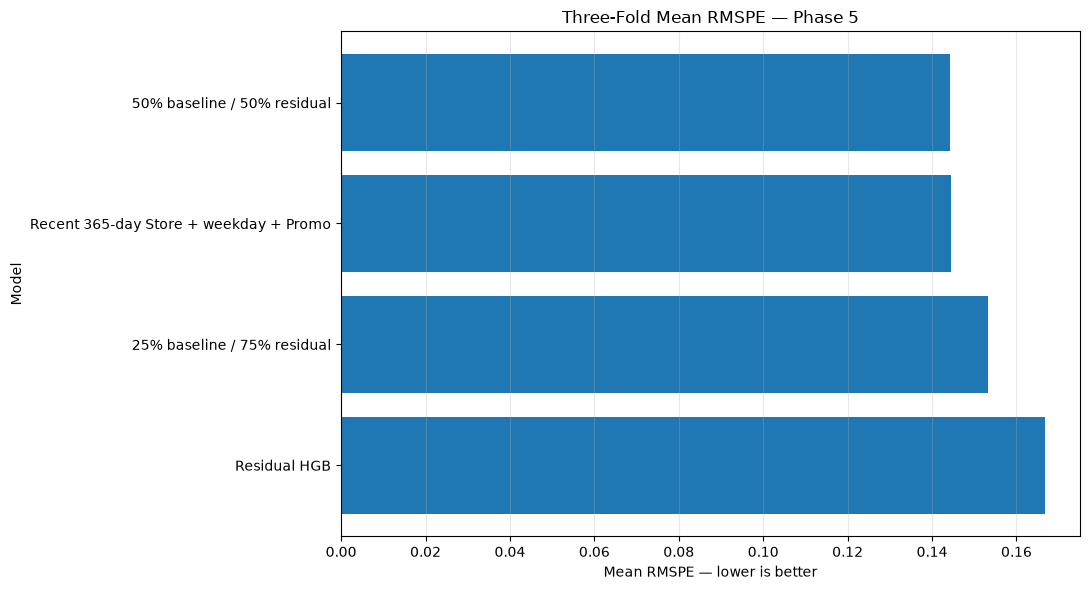

In [33]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_summary = residual_model_summary.sort_values(
    "mean_rmspe",
    ascending=False,
)

ax.barh(
    plot_summary["model"],
    plot_summary["mean_rmspe"],
)

ax.set_title("Three-Fold Mean RMSPE — Phase 5")
ax.set_xlabel("Mean RMSPE — lower is better")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

phase5_model_figure_path = (
    REPORT_FIGURES_DIR
    / "phase5_model_rmspe_comparison.png"
)

fig.savefig(
    phase5_model_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 10. Save compact Phase 5 outputs

The fitted residual models are not persisted until the final model-selection decision.

In [34]:
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

output_tables = {
    "phase5_baseline_backtest.csv": baseline_backtest,
    "phase5_baseline_model_summary.csv": baseline_model_summary,
    "phase5_residual_backtest.csv": residual_backtest,
    "phase5_residual_model_summary.csv": residual_model_summary,
    "phase5_residual_fit_summary.csv": residual_fit_summary,
    "phase5_final_fold_comparison.csv": final_fold_comparison,
    "phase5_final_fold_predictions.csv": final_fold_prediction_table,
    "phase5_weekday_diagnostics.csv": weekday_phase5_diagnostics,
    "phase5_daily_predictions.csv": daily_phase5_predictions,
}

print("Saved:")

for file_name, dataframe in output_tables.items():
    file_path = REPORT_TABLES_DIR / file_name
    dataframe.to_csv(file_path, index=False)
    print(f"- {file_path.relative_to(PROJECT_ROOT)}")

print(f"- {phase5_daily_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {phase5_model_figure_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\phase5_baseline_backtest.csv
- reports\tables\phase5_baseline_model_summary.csv
- reports\tables\phase5_residual_backtest.csv
- reports\tables\phase5_residual_model_summary.csv
- reports\tables\phase5_residual_fit_summary.csv
- reports\tables\phase5_final_fold_comparison.csv
- reports\tables\phase5_final_fold_predictions.csv
- reports\tables\phase5_weekday_diagnostics.csv
- reports\tables\phase5_daily_predictions.csv
- reports\figures\phase5_daily_actual_vs_predicted.png
- reports\figures\phase5_model_rmspe_comparison.png


## Stop and review

Share the following before committing:

1. `fold_definition`
2. `baseline_model_summary`
3. selected historical baseline and its average RMSPE
4. `residual_fit_summary`
5. `residual_model_summary`
6. selected Phase 5 model and its average RMSPE
7. `final_fold_comparison`
8. `weekday_phase5_diagnostics`
9. both Phase 5 charts
10. any warning or error

### Decisions after review

- Did recent history improve the long-term baseline consistently?
- Did the residual model improve average RMSPE across all three folds?
- Is the improvement also present in the final Phase 4 validation fold?
- Does blending reduce instability?
- Which candidate should be retrained for the Kaggle test?